In [4]:
#importing libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [5]:
#importing the dataset

data = pd.read_csv('C:/Users/Sayali/Desktop/Final-Year-Project-/backend/data/fertilizer_dataset/raw/f2.csv')
data.head()

,Temparature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer
0,20,83,26,Clayey,rice,90,49,36,Urea
1,25,84,32,Loamy,rice,66,59,36,Urea
2,33,64,50,Loamy,Wheat,41,0,0,Urea
3,34,65,54,Loamy,Wheat,38,0,0,Urea
4,38,72,51,Loamy,Wheat,39,0,0,Urea


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 552 entries, 0 to 551
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Temparature  552 non-null    int64 
 1   Humidity     552 non-null    int64 
 2   Moisture     552 non-null    int64 
 3   Soil_Type    552 non-null    object
 4   Crop_Type    552 non-null    object
 5   Nitrogen     552 non-null    int64 
 6   Potassium    552 non-null    int64 
 7   Phosphorous  552 non-null    int64 
 8   Fertilizer   552 non-null    object
dtypes: int64(6), object(3)
memory usage: 38.9+ KB


In [7]:
#changing the column names
data.rename(columns={'Temparature': 'Temperature'},inplace=True)

In [8]:
#checking unique values
data.nunique()

Temperature    21
Humidity       34
Moisture       41
Soil_Type       5
Crop_Type      17
Nitrogen       47
Potassium      31
Phosphorous    36
Fertilizer     14
dtype: int64

In [9]:
#checking for null values
data.isna().sum()

Temperature    0
Humidity       0
Moisture       0
Soil_Type      0
Crop_Type      0
Nitrogen       0
Potassium      0
Phosphorous    0
Fertilizer     0
dtype: int64

In [10]:
data['Fertilizer'].unique()

array(['Urea', 'TSP', 'Superphosphate', 'Potassium sulfate.',
       'Potassium chloride', 'DAP', '28-28', '20-20', '17-17-17',
       '15-15-15', '14-35-14', '14-14-14', '10-26-26', '10-10-2010'],
      dtype=object)

In [11]:
data['Crop_Type'].unique()

array(['rice', 'Wheat', 'Tobacco', 'Sugarcane', 'Pulses', 'pomegranate',
       'Paddy', 'Oil seeds', 'Millets', 'Maize', 'Ground Nuts', 'Cotton',
       'coffee', 'watermelon', 'Barley', 'kidneybeans', 'orange'],
      dtype=object)

In [12]:
#statistical parameters
data.describe(include='all')

,Temperature,Humidity,Moisture,Soil_Type,Crop_Type,Nitrogen,Potassium,Phosphorous,Fertilizer
count,552.000000,552.000000,552.000000,552,552,552.000000,552.000000,552.000000,552
unique,NaN,NaN,NaN,5,17,NaN,NaN,NaN,14
top,NaN,NaN,NaN,Loamy,Cotton,NaN,NaN,NaN,Urea
freq,NaN,NaN,NaN,192,64,NaN,NaN,NaN,108
mean,28.630435,64.557971,42.840580,NaN,NaN,28.521739,10.144928,21.115942,NaN
std,5.088082,11.880236,11.507275,NaN,NaN,29.121989,13.456956,14.920514,NaN
min,0.000000,50.000000,25.000000,NaN,NaN,0.000000,0.000000,0.000000,NaN
25%,26.000000,54.000000,33.000000,NaN,NaN,10.000000,0.000000,8.000000,NaN
50%,29.000000,62.000000,41.000000,NaN,NaN,15.000000,0.000000,20.000000,NaN
75%,32.000000,68.000000,51.000000,NaN,NaN,37.000000,18.000000,36.000000,NaN


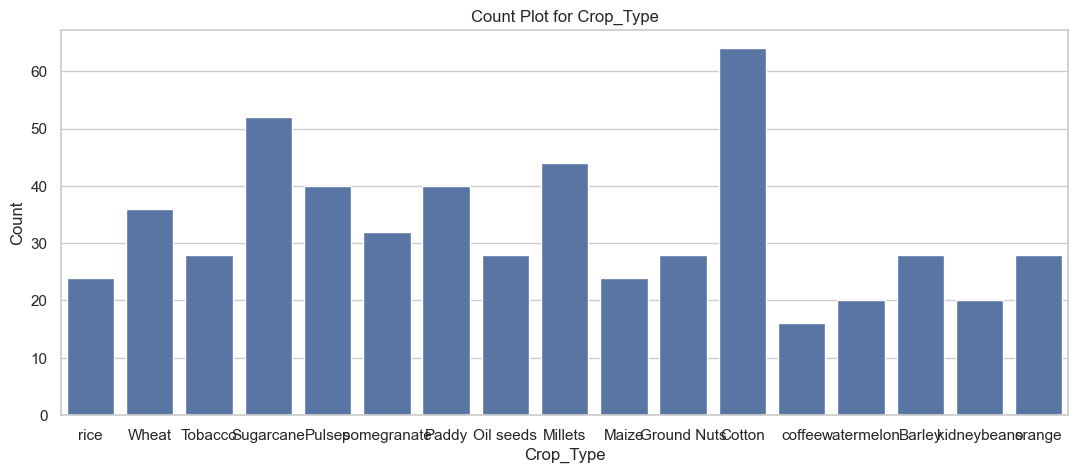

In [13]:
plt.figure(figsize=(13, 5))
sns.set(style="whitegrid")
sns.countplot(data=data, x='Crop_Type')
plt.title('Count Plot for Crop_Type')
plt.xlabel('Crop_Type')
plt.ylabel('Count')
plt.show()

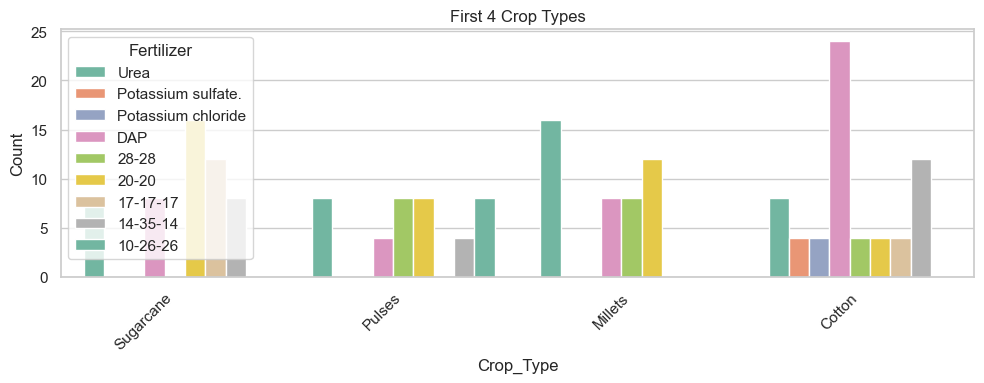

In [14]:
#first 4 crop types
part1_data = data[data['Crop_Type'].isin(data['Crop_Type'].value_counts().index[:4])]

# Create the first countplot
plt.figure(figsize=(10, 4))
sns.set(style="whitegrid")
sns.countplot(data=part1_data, x='Crop_Type', hue='Fertilizer', width=0.8, palette='Set2')
plt.title('First 4 Crop Types')
plt.xlabel('Crop_Type')
plt.ylabel('Count')
plt.legend(title='Fertilizer')
plt.xticks(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

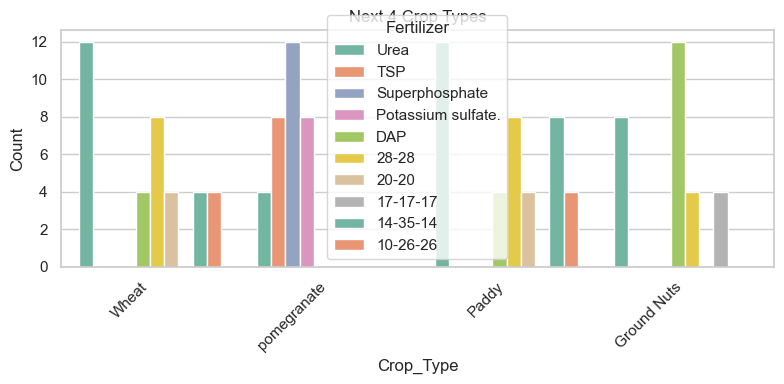

In [15]:
# Split the data into three parts: next 4 crop types
part2_data = data[data['Crop_Type'].isin(data['Crop_Type'].value_counts().index[4:8])]

# Create the second countplot
plt.figure(figsize=(8, 4))
sns.set(style="whitegrid")
sns.countplot(data=part2_data, x='Crop_Type', hue='Fertilizer', width=0.8, palette='Set2')
plt.title('Next 4 Crop Types')
plt.xlabel('Crop_Type')
plt.ylabel('Count')
plt.legend(title='Fertilizer')
plt.xticks(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()

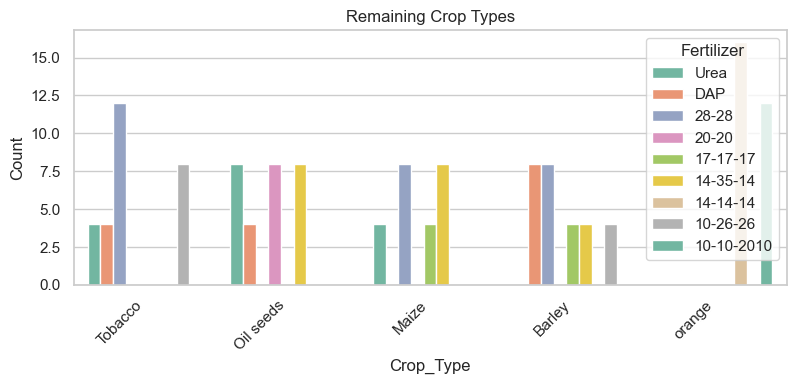

In [16]:
# Split the data into three parts: remaining crop types
part3_data = data[data['Crop_Type'].isin(data['Crop_Type'].value_counts().index[8:13])]

# Create the third countplot
plt.figure(figsize=(8, 4))
sns.set(style="whitegrid")
sns.countplot(data=part3_data, x='Crop_Type', hue='Fertilizer', width=0.8, palette='Set2')
plt.title('Remaining Crop Types')
plt.xlabel('Crop_Type')
plt.ylabel('Count')
plt.legend(title='Fertilizer')
plt.xticks(rotation=45, horizontalalignment='right')
plt.tight_layout()
plt.show()


<Axes: >

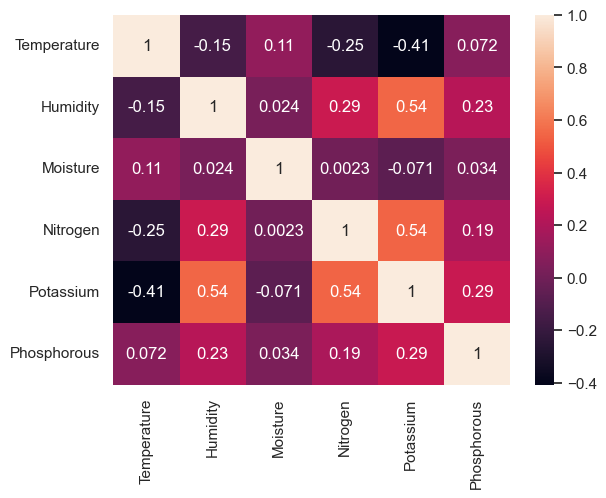

In [17]:
#Heatmap for Correlation Analysis

# Select only numeric columns for correlation analysis
numeric_data = data.select_dtypes(include=[np.number])
sns.heatmap(numeric_data.corr(), annot=True)

here is no such correlation between any of variables

In [18]:
from sklearn.preprocessing import LabelEncoder

In [19]:
#encoding Soil Type variable
encode_soil = LabelEncoder()

#fitting the label encoder
data.Soil_Type = encode_soil.fit_transform(data.Soil_Type)

#creating the DataFrame
Soil_Type = pd.DataFrame(zip(encode_soil.classes_,encode_soil.transform(encode_soil.classes_)),columns=['Original','Encoded'])
Soil_Type = Soil_Type.set_index('Original')
Soil_Type

,Encoded
Original,
Black,0
Clayey,1
Loamy,2
Red,3
Sandy,4


In [20]:
#encoding Crop Type variable
encode_crop = LabelEncoder()

#fitting the label encoder
data.Crop_Type = encode_crop.fit_transform(data.Crop_Type)

#creating the DataFrame
Crop_Type = pd.DataFrame(zip(encode_crop.classes_,encode_crop.transform(encode_crop.classes_)),columns=['Original','Encoded'])
Crop_Type = Crop_Type.set_index('Original')
Crop_Type

,Encoded
Original,
Barley,0
Cotton,1
Ground Nuts,2
Maize,3
Millets,4
Oil seeds,5
Paddy,6
Pulses,7
Sugarcane,8


In [21]:
#encoding Fertilizer variable
encode_ferti = LabelEncoder()

#fitting the label encoder
data.Fertilizer = encode_ferti.fit_transform(data.Fertilizer)

#creating the DataFrame
Fertilizer = pd.DataFrame(zip(encode_ferti.classes_,encode_ferti.transform(encode_ferti.classes_)),columns=['Original','Encoded'])
Fertilizer = Fertilizer.set_index('Original')
Fertilizer

,Encoded
Original,
10-10-2010,0
10-26-26,1
14-14-14,2
14-35-14,3
15-15-15,4
17-17-17,5
20-20,6
28-28,7
DAP,8


In [22]:

from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(data.drop('Fertilizer',axis=1),data.Fertilizer,test_size=0.2,random_state=1)



In [23]:
x_train.shape

(441, 8)

In [24]:
y_train.shape

(441,)

In [25]:
x_test.shape

(111, 8)

In [26]:
y_test.shape

(111,)

In [27]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Index: 441 entries, 213 to 37
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   Temperature  441 non-null    int64
 1   Humidity     441 non-null    int64
 2   Moisture     441 non-null    int64
 3   Soil_Type    441 non-null    int32
 4   Crop_Type    441 non-null    int32
 5   Nitrogen     441 non-null    int64
 6   Potassium    441 non-null    int64
 7   Phosphorous  441 non-null    int64
dtypes: int32(2), int64(6)
memory usage: 27.6 KB


In [28]:
acc = [] # TEST
model = []
acc1=[] # TRIAN

In [29]:
# Logistic regression model

#importing libraries
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import classification_report
from sklearn import metrics
from sklearn import tree
import warnings
warnings.filterwarnings('ignore')

ds = DecisionTreeClassifier(criterion="entropy",random_state=2,max_depth=5)
ds.fit(x_train,y_train)

predicted_values = ds.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)
model.append('Decision Tree')

predicted_values = ds.predict(x_train)
y = metrics.accuracy_score(y_train, predicted_values)
acc1.append(y)

print("DecisionTrees's Accuracy is: ", x*100, y*100)

print("classification_report", y_test,predicted_values)

DecisionTrees's Accuracy is:  90.09009009009009 93.42403628117914
classification_report 364     7
247    11
65      8
237    12
547     0
       ..
392     6
417     6
17     13
370     7
475     3
Name: Fertilizer, Length: 111, dtype: int32 [13  6  8  8  3  7  8  8 10 13  8  5 13 12 13 13  6  1 13  4 13  5  7  7
  6  1  3  8  3  2  5  8  8 13  7 13 13  7 10  1  8  4  1 10  8  8  5  0
  2  3  5 13  8  3  7  6  7  0 12  7  8 13  5  6  3  7 13  6 13  3  8  7
  7  5  6 13  4  4  6  6 13  8  7  8  6  3  2  8 13 13 13  6  8  6  7 10
  6  7  8 12  5  4  3  6  5  8  8  8  1  7 13  3 12  6  4  7 13  6 10 13
 13  8  7  8  6 10 10 10  5  0  8  1  7 13  1  8  3 13  1  8  7  8  0  8
 13 12  6  7  1 12 13  1  6 13  1 13  4 13  2 13  8  6  3  3  8 10  6  4
  0  7  5 12  3  7  7 13  7 13 13  8 13 13 13  7  3  3  6  6  8  3  3  5
  7 13  3  6 12  8  8  3 12  5  8  3  8 12  1  0 13 10  8 13  8  8  0  3
  7 13  4  8 10  7  8  6 13 12  5  2  3  8 12 12  8  5  8 13  4  3  8 12
  3  6 12 10  8  8  3  8  7 

In [30]:
from sklearn.naive_bayes import GaussianNB

NaiveBayes = GaussianNB()

NaiveBayes.fit(x_train,y_train)

predicted_values = NaiveBayes.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)

predicted_values = NaiveBayes.predict(x_train)
y = metrics.accuracy_score(y_train, predicted_values)
acc1.append(y)

model.append('Naive Bayes')
print("Naive Bayes's Accuracy is: ", x,y)

print("classification_report", y_test,predicted_values)

Naive Bayes's Accuracy is:  0.9459459459459459 0.9138321995464853
classification_report 364     7
247    11
65      8
237    12
547     0
       ..
392     6
417     6
17     13
370     7
475     3
Name: Fertilizer, Length: 111, dtype: int32 [ 8  6  8  8  3  7  9  8 11 13 12  5 13 11  8 13  6  1 13  4 13  5  7  7
  6  1  3  8  3  2  5  8  8 12  7 13 13  7 10  1  8  4  1 11  8  8  5  0
  2  3  5 13  8  3  7  6  7  4 12  7  8 13  5  6  3  7 13  6 13  3  8  7
  7  5  6  8  4  4  6  6 13  8  7  8  6  3  2  9 13 13 13  6  8  6  7 10
  6  7  8 11  5  1  3  6  5  8  8  8  1  7 12  3 12  6  4  7 13  6 11 13
 13  8  7  8  6 11 10 11  5  2  8  1  7 13  1  8  3 13  1  8  7  8  4  8
 13 12  6  7  1  8 13  1  6 13  1 13  4 13  2  8  8  6  3  3  8 10  6  4
  0  7  5 12  3  7  7 13  7 13 13  8 13 13 13  7  3  3  6  6  8  3  3  5
  7 13  3  6 12  8  8  3 12  5  8  3  8 11  1  4 13 10  8 13  8  8  0  3
  7 13  4  8 11  7  8  6 13 11  5  2  3  8 12 12  8  5  8 13  4  3  8  8
  3  6 12 11  8  8  3  8  7 

In [31]:
from sklearn.svm import SVC

from sklearn.preprocessing import MinMaxScaler
# fit scaler on training data
norm = MinMaxScaler().fit(x_train)
X_train_norm = norm.transform(x_train)
# transform testing dataabs
X_test_norm = norm.transform(x_test)
SVM = SVC(kernel='poly', degree=3, C=1)
SVM.fit(X_train_norm,y_train)

predicted_values = SVM.predict(X_test_norm)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)

predicted_values = SVM.predict(X_train_norm)
y = metrics.accuracy_score(y_train, predicted_values)
acc1.append(y)

model.append('SVM')
print("SVM's Accuracy is: ", x,y)

print("classification_report",y_test,predicted_values)

SVM's Accuracy is:  0.990990990990991 0.9931972789115646
classification_report 364     7
247    11
65      8
237    12
547     0
       ..
392     6
417     6
17     13
370     7
475     3
Name: Fertilizer, Length: 111, dtype: int32 [13  6  8  8  3  7  9  8 11 13  8  5 13 12 13 13  6  1 13  4 13  5  7  7
  6  1  3  8  3  2  5  8  8 13  7 13 13  7 10  1  8  4  1 11  8  8  5  0
  2  3  5 13  8  3  7  6  7  0 12  7  8 13  5  6  3  7 13  6 13  3  8  7
  7  5  6 13  4  4  6  6 13  8  7  8  6  3  2  9 13 13 13  6  8  6  7 10
  6  7  8 12  5  1  3  6  5  8  8  8  1  7 13  3 12  6  4  7 13  6 11 13
 13  8  7  8  6 10 10 11  5  2  8  1  7 13  1  8  3 13  1  8  7  8  0  8
 13 12  6  7  1  8 13  1  6 13  1 13  4 13  2 13  8  6  3  3  8 10  6  4
  0  7  5 12  3  7  7 13  7 13 13  8 13 13 13  7  3  3  6  6  8  3  3  5
  7 13  3  6 12  8  8  3 12  5  8  3  8 12  1  0 13 10  8 13  8  8  0  3
  7 13  4  8 11  7  8  6 13 12  5  2  3  8 12 12  8  5  8 13  4  3  8  8
  3  6 12 11  8  8  3  8  7 12  0  7 

In [32]:
from sklearn.linear_model import LogisticRegression

LogReg = LogisticRegression(random_state=2)

LogReg.fit(x_train,y_train)

predicted_values = LogReg.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)

predicted_values = LogReg.predict(x_train)
y = metrics.accuracy_score(y_train, predicted_values)
acc1.append(y)

model.append('Logistic Regression')
print("Logistic Regression's Accuracy is: ", x,y)

print("classification_report",y_test,predicted_values)

Logistic Regression's Accuracy is:  0.7837837837837838 0.909297052154195
classification_report 364     7
247    11
65      8
237    12
547     0
       ..
392     6
417     6
17     13
370     7
475     3
Name: Fertilizer, Length: 111, dtype: int32 [13  6  8  8  3  7  8  3 11 13 12  5 13 10 13 13  6  1 13  4 13  5  7  7
  6  1  3  8  3  2  5  8  8 13  7 13 13  7 12  1  8  4  1 11  8  8  5  0
  2  3  5 13  8  3  7  6  7  0  8  7  8 13  5  6  3  7 13  6 13  3  8  7
  7  5  6 12  4  4  6  6 13  8  7  8  6  3  2  8 13 13 13  6  8  6  7 10
  6  7  8 10  5  1  3  6  5  3  8  8  1  7 13  3 12  6  4  7 13  6 11 13
 13  8  7  8  6 10 10 11  5  2  8  1  7 13  1  8  3 13  1  8  7  8  0  8
 13 13  6  7  1 12 13  1  6 13  1 13  4 13  2 12  8  6  3  3  8 10  6  4
  0  7  5 12  3  7  7 13  7 13 13  8 13 13 13  7  3  3  6  6  8  3  3  5
  7 13  3  6 12  8  8  3 12  5  8  3  8 10  1  0 13 12  8 13  8  8  0  3
  7 13  4  8 11  7  8  6 13 12  5  2  3  8  8  8  8  5  8 13 13  3  8 12
  3  6 13 11  8  8  3

In [33]:
from lightgbm import LGBMClassifier

LGBM = LGBMClassifier(n_estimators=200, learning_rate=0.1, num_leaves=31, random_state=0)
LGBM.fit(x_train, y_train)

predicted_values = LGBM.predict(x_test)
x = metrics.accuracy_score(y_test, predicted_values)
acc.append(x)

predicted_values = LGBM.predict(x_train)
y = metrics.accuracy_score(y_train, predicted_values)
acc1.append(y)

model.append('LightGBM')
print("LightGBM's Accuracy is: ", x, y)

print("classification_report", y_test, predicted_values)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000161 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 228
[LightGBM] [Info] Number of data points in the train set: 441, number of used features: 8
[LightGBM] [Info] Start training from score -3.604138
[LightGBM] [Info] Start training from score -3.198673
[LightGBM] [Info] Start training from score -3.380995
[LightGBM] [Info] Start training from score -2.304855
[LightGBM] [Info] Start training from score -3.604138
[LightGBM] [Info] Start training from score -2.998002
[LightGBM] [Info] Start training from score -2.327845
[LightGBM] [Info] Start training from score -2.100061
[LightGBM] [Info] Start training from score -1.611708
[LightGBM] [Info] Start training from score -4.990433
[LightGBM] [Info] Start training from score -3.786460
[LightGBM] [Info] Start training from score -3.891820
[Li

In [34]:
from sklearn.model_selection import cross_val_score

score = cross_val_score(LGBM, data, data.Fertilizer, cv=5)
print("Cross-validation score of LightGBM :", score)
score = cross_val_score(LogReg, data, data.Fertilizer, cv=5)
print("Cross-validation score of LogReg :", score)
score = cross_val_score(SVM, data, data.Fertilizer, cv=5)
print("Cross-validation score of SVM :", score)
score = cross_val_score(NaiveBayes, data, data.Fertilizer, cv=5)
print("Cross-validation score of NaiveBayes :", score)
score = cross_val_score(ds, data, data.Fertilizer, cv=5)
print("Cross-validation score of ds :", score)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000228 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 248
[LightGBM] [Info] Number of data points in the train set: 441, number of used features: 9
[LightGBM] [Info] Start training from score -3.524096
[LightGBM] [Info] Start training from score -2.998002
[LightGBM] [Info] Start training from score -3.524096
[LightGBM] [Info] Start training from score -2.282382
[LightGBM] [Info] Start training from score -3.604138
[LightGBM] [Info] Start training from score -2.953551
[LightGBM] [Info] Start training from score -2.282382
[LightGBM] [Info] Start training from score -2.100061
[LightGBM] [Info] Start training from score -1.670204
[LightGBM] [Info] Start training from score -4.990433
[LightGBM] [Info] Start training from score -3.786460
[LightGBM] [Info] Start training from score -3.786460
[Li

[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No f

<Axes: title={'center': 'Accuracy Comparison'}, xlabel='Accuracy', ylabel='Algorithm'>

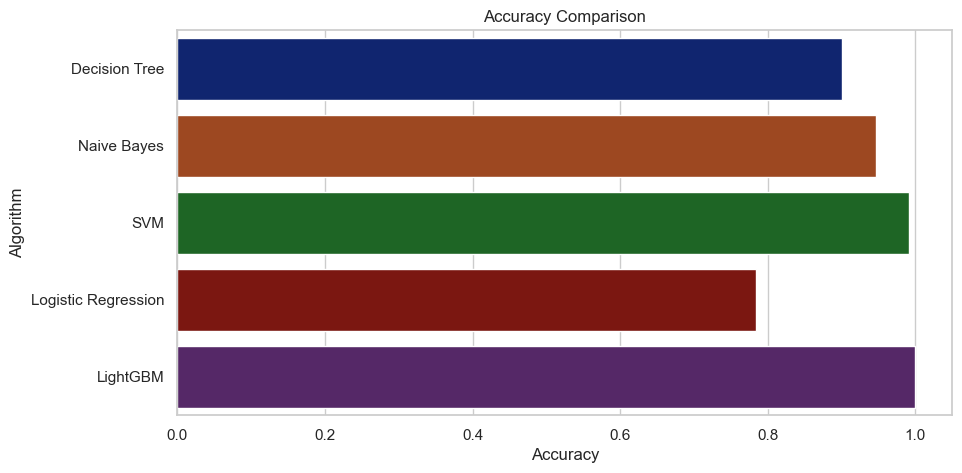

In [35]:
plt.figure(figsize=[10,5],dpi = 100)
plt.title('Accuracy Comparison')
plt.xlabel('Accuracy')
plt.ylabel('Algorithm')
sns.barplot(x = acc,y = model,palette='dark')

In [36]:
import pickle
pickle_out = open('classifier.pkl','wb')
pickle.dump(LGBM,pickle_out)
pickle_out.close()

In [37]:
model = pickle.load(open('classifier.pkl','rb'))
model.predict([[34,67,62,0,1,7,0,30]])

array([3])

In [38]:
model = pickle.load(open('classifier.pkl','rb'))
model.predict([[25,78,43,4,1,22,26,38]])

array([10])

In [39]:
#pickling the file
import pickle
pickle_out = open('fertilizer.pkl','wb')
pickle.dump(encode_ferti,pickle_out)
pickle_out.close()

In [40]:
ferti = pickle.load(open('fertilizer.pkl','rb'))
ferti.classes_[1]

'10-26-26'

In [41]:
print(data['Fertilizer'].unique())

[13 12 11 10  9  8  7  6  5  4  3  2  1  0]


In [42]:
print(type(model))  # Expect <class 'lightgbm.sklearn.LGBMClassifier'>


<class 'lightgbm.sklearn.LGBMClassifier'>


In [43]:
import pickle
m = pickle.load(open('classifier.pkl','rb'))
print(type(m))  # should show lightgbm.sklearn.LGBMClassifier

<class 'lightgbm.sklearn.LGBMClassifier'>
